# Phrase Embedding Examples

In [165]:
import openai
import numpy as np
import matplotlib.pyplot as plt

In [166]:
client = openai.AsyncOpenAI()

In [167]:
response = await client.responses.create(
    model='gpt-4o-mini',
    input='hi'
)

In [168]:
response.output_text

'Hello! How can I assist you today?'

In [169]:
# Experiment: Negations
phrases = [
    # Positive terms
    'happy', 'good', 'successful', 'healthy', 'wealthy',
    # Negations with "not"
    'not happy', 'not good', 'not successful', 'not healthy', 'not wealthy',
    # Negative prefixes (un-, in-, dis-)
    'unhappy', 'bad', 'unsuccessful', 'unhealthy', 'poor',
    # Antonyms
    'sad', 'evil', 'failure', 'sick', 'broke',
    # Neutral/Unrelated
    'table', 'computer', 'blue'
]

response = await client.embeddings.create(
    input=phrases,
    model='text-embedding-3-small'
)

In [170]:
embeds = np.array([emb.embedding for emb in response.data])

In [171]:
embeds

array([[ 0.01881682, -0.01838269, -0.05507363, ..., -0.01110155,
        -0.00494298, -0.01004722],
       [ 0.00237041,  0.00672447, -0.01960961, ...,  0.01205317,
        -0.00531495, -0.01896329],
       [ 0.04105618, -0.01237035, -0.0068739 , ...,  0.00769636,
         0.01096614, -0.01067862],
       ...,
       [ 0.00525164, -0.01114878,  0.04535288, ..., -0.01199073,
         0.03533371, -0.02295709],
       [-0.01090149,  0.00782294, -0.00555964, ..., -0.03166847,
         0.00890013,  0.02289783],
       [-0.00112757, -0.01652919, -0.01312013, ..., -0.01681994,
         0.02126843,  0.00448847]], shape=(23, 1536))

In [172]:
async def embed(text:str ) -> np.ndarray:
    response = await client.embeddings.create(
        input=[text],
        model='text-embedding-3-small'
    )
    return np.array(response.data[0].embedding)

In [173]:
# Query: test negation understanding
phrase = 'miserable'
query = await embed(phrase)

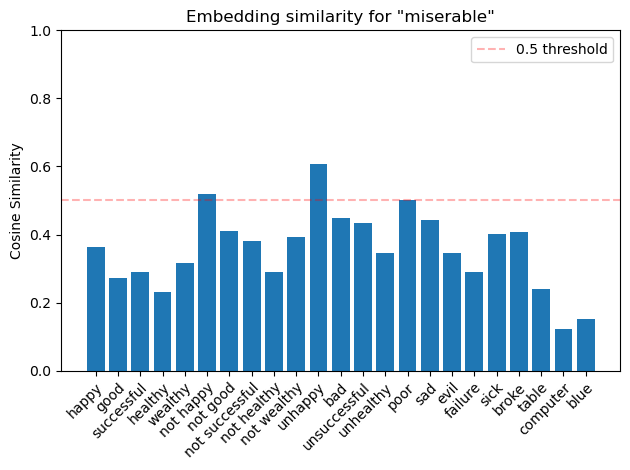

In [174]:
# Visualize similarity scores
ax = plt.bar(x=range(len(phrases)), height=(query @ embeds.T))
plt.xticks(range(len(phrases)), phrases, rotation=45, ha='right', rotation_mode='anchor')
plt.title(f'Embedding similarity for "{phrase}"')
plt.ylabel('Cosine Similarity')
plt.ylim([0, 1])
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='0.5 threshold')
plt.legend()
plt.tight_layout()